In [ ]:
import pandas as pd
import numpy as np

# Loading
#data_set = pd.read_csv("drive/MyDrive/neural/adult.data")
data_set = pd.read_csv("drive/MyDrive/neural/agaricus-lepiota.data")

data_set = data_set.map(lambda x: x.strip() if isinstance(x, str) else x)

x =  data_set.iloc[:,1:].values
y =  data_set.iloc[:,0].values

feature = data_set.keys().map(lambda x: x.strip() if isinstance(x, str) else x)

# Filling
from sklearn.impute import SimpleImputer

cat_col_indices = [0]
for i in cat_col_indices:
    x[:, i] = np.where(x[:, i] == '?', np.nan, x[:, i])
    x[:, i] = SimpleImputer(strategy='most_frequent').fit_transform(x[:, i].reshape(-1,1)).ravel()

# Encoding
from sklearn.preprocessing import LabelEncoder
encoders = []
for i in range(x.shape[1]):
    le = LabelEncoder()
    x[:, i] = le.fit_transform(x[:, i])
    encoders.append(le)

# Normilizing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
st_x= MinMaxScaler()
x = st_x.fit_transform(x)

#st_y = MinMaxScaler()

le_y = LabelEncoder()
y = le_y.fit_transform(y)

y = y.reshape(-1,1)
#y = st_y.fit_transform(y)


TRAIN_COEF = 0.7


TRAIN_COUNT = int(TRAIN_COEF * x.shape[0])
VAL_COUNT = x.shape[0] - TRAIN_COUNT

X_train_o = x[0:TRAIN_COUNT,:]
Y_train_o = y[0:TRAIN_COUNT].reshape(-1)
X_val_o = x[TRAIN_COUNT:,:]
Y_val_o = y[TRAIN_COUNT:].reshape(-1)


In [ ]:
Y_train_o

array([0, 0, 1, ..., 1, 1, 0])

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train = torch.tensor(X_train_o, dtype=torch.float32)
Y_train = torch.tensor(Y_train_o, dtype=torch.float32).long()

X_val = torch.tensor(X_val_o, dtype=torch.float32)
Y_val = torch.tensor(Y_val_o, dtype=torch.float32).long()

INPUT_SIZE = x.shape[1]
CLASSES_COUNT = 2

model = nn.Sequential(
            nn.Linear(INPUT_SIZE, 32),
            nn.ReLU(),
            nn.Linear(32, CLASSES_COUNT)
        )

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)


epochs = 50
batch_size = 64

In [ ]:
Y_train

tensor([0, 0, 1,  ..., 1, 1, 0])

Epoch 0, train_loss=0.851068, val_loss=0.855955
Epoch 10, train_loss=0.730515, val_loss=0.646648
Epoch 20, train_loss=0.665972, val_loss=0.492015
Epoch 30, train_loss=0.607626, val_loss=0.408076
Epoch 40, train_loss=0.540193, val_loss=0.359252


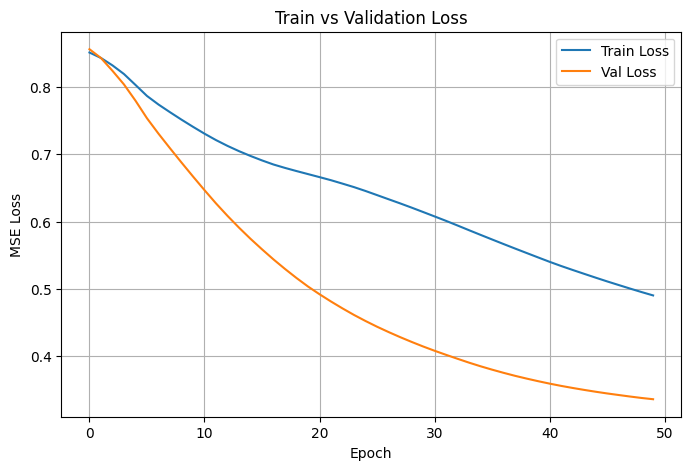

In [ ]:
import matplotlib.pyplot as plt

train_losses = []
val_losses = []

for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = Y_train[i:i+batch_size]

        # forward
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, Y_val)


    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:

        print(f"Epoch {epoch}, train_loss={loss.item():.6f}, val_loss={val_loss.item():.6f}")


plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def compute_accuracy(model, X, Y):
    model.eval()

    with torch.no_grad():
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        correct = (preds == Y).sum().item()
        total = Y.size(0)

    return correct / total

train_acc = compute_accuracy(model, X_train, Y_train)
val_acc = compute_accuracy(model, X_val, Y_val)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Val accuracy:   {val_acc:.4f}")

Train accuracy: 0.9444
Val accuracy:   0.8999


In [ ]:
import numpy as np

class NeuralNetwork:
    def __init__(self, input_size, h_size, out_size, X_train, Y_train, X_val=None, Y_val=None):
        self.X_train = X_train
        self.Y_train = Y_train
        self.X_val = X_val
        self.Y_val = Y_val

        self.W1 = np.random.randn(input_size, h_size) * 0.01
        self.b1 = np.zeros((1, h_size))
        self.W2 = np.random.randn(h_size, out_size) * 0.01
        self.b2 = np.zeros((1, out_size))

        self.out_size = out_size

        self.ALPHA = 0.002
        self.epochs = 150
        self.batch_size = 32

    def forward(self, x):
        t1 = x @ self.W1 + self.b1
        h1 = self.relu(t1)
        t2 = h1 @ self.W2 + self.b2
        z = self.softmax_batch(t2)
        return t1, h1, t2, z

    def predict(self, x):
        _, _, _, z = self.forward(x)
        return np.argmax(z, axis=1)

    def relu(self, t):
        return np.maximum(t, 0)

    def relu_deriv(self, t):
        return (t > 0).astype(float)

    def softmax_batch(self, t):
        t = t - np.max(t, axis=1, keepdims=True)
        exp = np.exp(t)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def sparse_cross_entropy_batch(self, z, y):
        return -np.log(z[np.arange(len(y)), y] + 1e-9)

    def to_full_batch(self, y, num_classes):
        y_full = np.zeros((len(y), num_classes))
        y_full[np.arange(len(y)), y] = 1
        return y_full

    def compute_loss(self, X, y):
        _, _, _, z = self.forward(X)
        return np.mean(self.sparse_cross_entropy_batch(z, y))

    def train(self):
        train_losses = []
        val_losses = []

        for epoch in range(self.epochs):
            indices = np.random.permutation(len(self.X_train))
            self.X_train = self.X_train[indices]
            self.Y_train = self.Y_train[indices]

            epochE = 0

            for i in range(0, len(self.X_train), self.batch_size):
                X_batch = self.X_train[i:i+self.batch_size]
                y_batch = self.Y_train[i:i+self.batch_size]

                # forward
                t1, h1, t2, z = self.forward(X_batch)

                E = np.mean(self.sparse_cross_entropy_batch(z, y_batch))

                # one-hot
                y_full = self.to_full_batch(y_batch, self.out_size)

                # backward
                dE_dt2 = (z - y_full) / len(y_batch)

                dE_dW2 = h1.T @ dE_dt2
                dE_db2 = np.sum(dE_dt2, axis=0, keepdims=True)

                dE_dh1 = dE_dt2 @ self.W2.T
                dE_dt1 = dE_dh1 * self.relu_deriv(t1)

                dE_dW1 = X_batch.T @ dE_dt1
                dE_db1 = np.sum(dE_dt1, axis=0, keepdims=True)

                self.W1 -= self.ALPHA * dE_dW1
                self.b1 -= self.ALPHA * dE_db1
                self.W2 -= self.ALPHA * dE_dW2
                self.b2 -= self.ALPHA * dE_db2

                epochE += E

            train_loss = epochE / (len(self.X_train) / self.batch_size)
            train_losses.append(train_loss)

            if self.X_val is not None:
                val_loss = self.compute_loss(self.X_val, self.Y_val)
                val_losses.append(val_loss)
            else:
                val_loss = None

            if epoch % 10 == 0:
                print(f"Epoch {epoch}, train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

        return train_losses, val_losses



Epoch 0, train_loss=0.6884, val_loss=0.7164
Epoch 10, train_loss=0.6497, val_loss=0.8479
Epoch 20, train_loss=0.5968, val_loss=0.8769
Epoch 30, train_loss=0.4796, val_loss=0.8366
Epoch 40, train_loss=0.3720, val_loss=0.6638
Epoch 50, train_loss=0.3054, val_loss=0.5090
Epoch 60, train_loss=0.2673, val_loss=0.4220
Epoch 70, train_loss=0.2404, val_loss=0.3743
Epoch 80, train_loss=0.2182, val_loss=0.3500
Epoch 90, train_loss=0.2008, val_loss=0.3347
Epoch 100, train_loss=0.1866, val_loss=0.3278
Epoch 110, train_loss=0.1751, val_loss=0.3257
Epoch 120, train_loss=0.1651, val_loss=0.3258
Epoch 130, train_loss=0.1567, val_loss=0.3264
Epoch 140, train_loss=0.1495, val_loss=0.3288


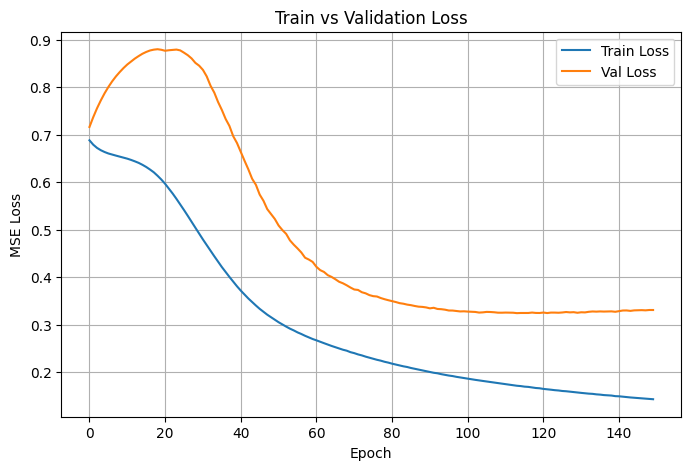

In [ ]:
net = NeuralNetwork(
    input_size=x.shape[1],
    h_size=32,
    out_size=2,
    X_train=X_train_o, Y_train=Y_train_o, X_val=X_val_o, Y_val=Y_val_o
    )

net_losses,net_val_losses = net.train()


plt.figure(figsize=(8,5))
plt.plot(net_losses, label='Train Loss')
plt.plot(net_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()